In [1]:
# ==========================================
# IMPORT LIBRARIES
# ==========================================

# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display options
pd.set_option('display.max_columns', None)

# Plot style
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10,6)

In [2]:
# ==========================================
# LOAD DATASET
# ==========================================

# Read Excel file
df = pd.read_excel("Flight_Price.xlsx")

# Display first five rows
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [3]:
# ==========================================
# DATA UNDERSTANDING
# ==========================================

# Number of rows and columns
print("Dataset Shape:", df.shape)

# Data types
df.info()

Dataset Shape: (10683, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


In [4]:
# Summary statistics
df.describe(include='all')

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
count,10683,10683,10683,10683,10682,10683,10683,10683,10682,10683,10683.000000
unique,12,44,5,6,128,222,1343,368,5,10,NaN
top,Jet Airways,18/05/2019,Delhi,Cochin,DEL → BOM → COK,18:55,19:00,2h 50m,1 stop,No info,NaN
freq,3849,504,4537,4537,2376,233,423,550,5625,8345,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9087.064121
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4611.359167
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1759.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5277.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8372.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12373.000000


In [5]:
# ==========================================
# DATA QUALITY CHECK
# ==========================================

# Missing values
df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

In [6]:
# Duplicate records
df.duplicated().sum()

np.int64(220)

In [7]:
# Unique values in each column
df.nunique()

Airline              12
Date_of_Journey      44
Source                5
Destination           6
Route               128
Dep_Time            222
Arrival_Time       1343
Duration            368
Total_Stops           5
Additional_Info      10
Price              1870
dtype: int64

In [8]:
# ==========================================
# DATA CLEANING
# ==========================================

# Remove duplicate rows
df = df.drop_duplicates()

# Convert journey date to datetime
df['Date_of_Journey'] = pd.to_datetime(
    df['Date_of_Journey'],
    format='%d/%m/%Y'
)

# Verify data types
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10463 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Airline          10463 non-null  object        
 1   Date_of_Journey  10463 non-null  datetime64[ns]
 2   Source           10463 non-null  object        
 3   Destination      10463 non-null  object        
 4   Route            10462 non-null  object        
 5   Dep_Time         10463 non-null  object        
 6   Arrival_Time     10463 non-null  object        
 7   Duration         10463 non-null  object        
 8   Total_Stops      10462 non-null  object        
 9   Additional_Info  10463 non-null  object        
 10  Price            10463 non-null  int64         
dtypes: datetime64[ns](1), int64(1), object(9)
memory usage: 980.9+ KB


In [9]:
# Duplicate records
df.duplicated().sum()

np.int64(0)

In [10]:
# Missing values
df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

In [11]:
# Filling Missing values for Route
df['Route']= df['Route'].fillna(df['Route'].mode()[0])

In [12]:
# Filling Missing values for total_Stops
df['Total_Stops']= df['Total_Stops'].fillna(df['Total_Stops'].mode()[0])

In [13]:
# Missing values
df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              0
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        0
Additional_Info    0
Price              0
dtype: int64

In [14]:
# ==========================================
# FEATURE ENGINEERING
# ==========================================

# Journey month
df['Journey_Month'] = df['Date_of_Journey'].dt.month_name()

# Journey day
df['Journey_Day'] = df['Date_of_Journey'].dt.day_name()

# Departure hour
df['Departure_Hour'] = pd.to_datetime(df['Dep_Time']).dt.hour

C:\Users\sujal\AppData\Local\Temp\ipykernel_19172\738913043.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Departure_Hour'] = pd.to_datetime(df['Dep_Time']).dt.hour


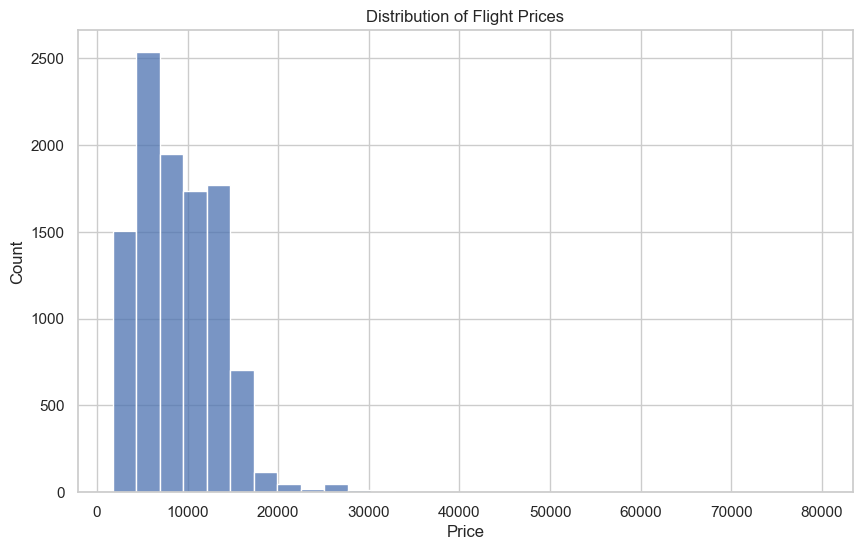

Airline
Jet Airways                          3700
IndiGo                               2043
Air India                            1695
Multiple carriers                    1196
SpiceJet                              815
Vistara                               478
Air Asia                              319
GoAir                                 194
Multiple carriers Premium economy      13
Jet Airways Business                    6
Vistara Premium economy                 3
Trujet                                  1
Name: count, dtype: int64

In [15]:
# ==========================================
# UNIVARIATE ANALYSIS
# ==========================================

# Price distribution
sns.histplot(df['Price'], bins=30)
plt.title("Distribution of Flight Prices")
plt.show()

# Airline frequency
df['Airline'].value_counts()

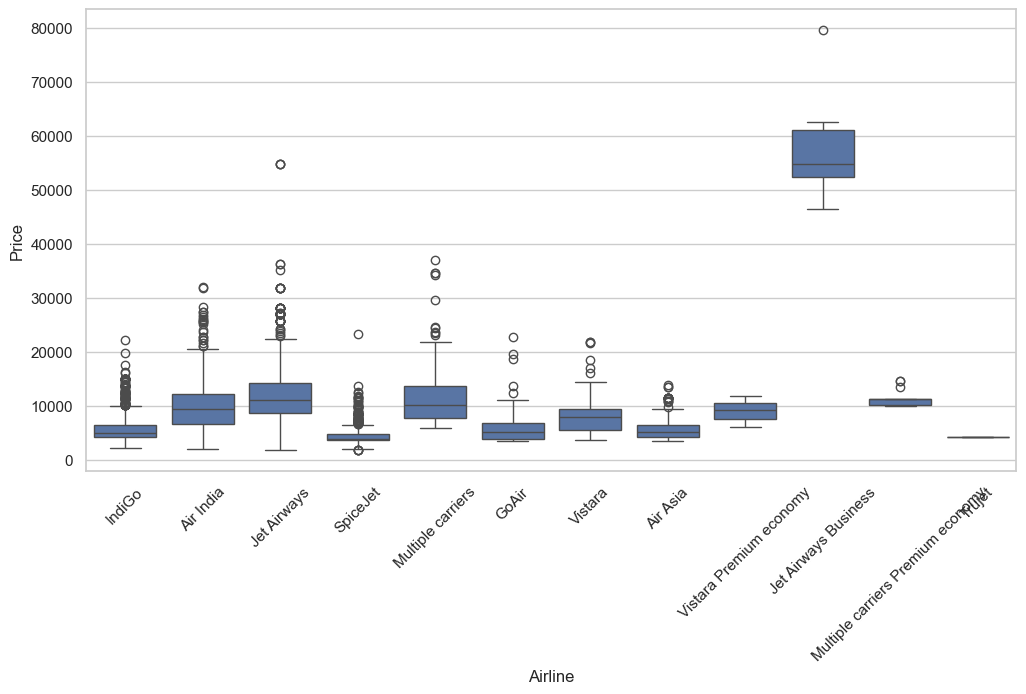

In [16]:
# ==========================================
# BIVARIATE ANALYSIS
# ==========================================

# Airline vs Price
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x='Airline',
    y='Price'
)

plt.xticks(rotation=45)
plt.show()

### Observation

- The average ticket prices vary noticeably across different airlines.
- Some airlines consistently have higher ticket prices, while others generally offer lower fares.
- The spread of prices within each airline indicates that ticket prices also vary depending on journey characteristics such as route, duration, and number of stops.

### Business Insight

The analysis suggests that **Airline** is an important factor influencing ticket prices. Differences in average fares indicate that each airline follows its own pricing strategy, which may reflect factors such as brand positioning, service quality, route coverage, and market demand.

### Conclusion

Airline should be considered one of the primary variables when analyzing or predicting flight ticket prices.

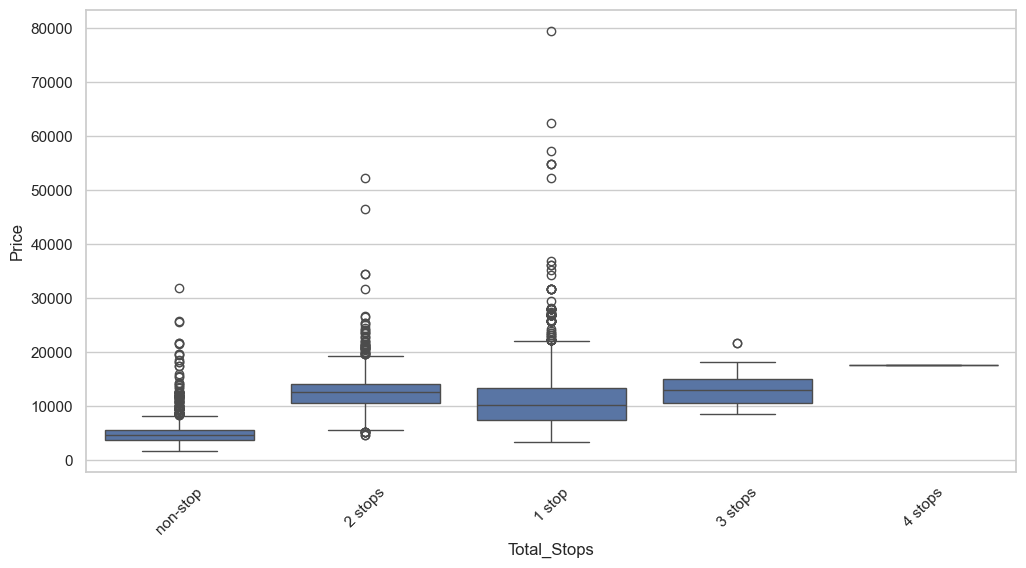

In [17]:
# Total_Stops vs Price
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x='Total_Stops',
    y='Price'
)

plt.xticks(rotation=45)
plt.show()

### Observation

- Ticket prices differ across flights with different numbers of stops.
- Flights with fewer stops may exhibit different pricing patterns than flights with multiple stops.
- Price variation exists within every stop category.

### Business Insight

The number of stops appears to influence ticket prices because it affects travel convenience and journey characteristics. Customers may be willing to pay more for direct or shorter journeys, while airlines may price connecting flights differently depending on demand and operational considerations.

### Conclusion

Total Stops is an important variable that contributes to airline ticket pricing.

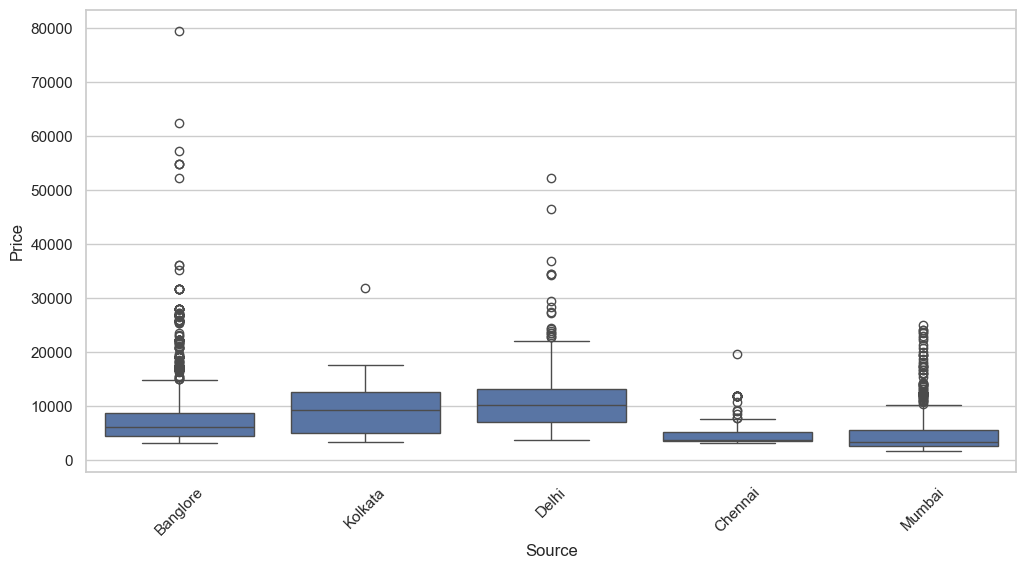

In [18]:
# Source vs Price
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x='Source',
    y='Price'
)

plt.xticks(rotation=45)
plt.show()

### Observation

- Average ticket prices vary across departure cities.
- Some source airports consistently show higher ticket prices than others.

### Business Insight

Departure location influences pricing due to differences in passenger demand, competition, airport operations, and route availability. Markets with higher demand or fewer competing airlines may experience higher fares.

### Conclusion

Source airport contributes to pricing differences and should be included when analyzing ticket prices.

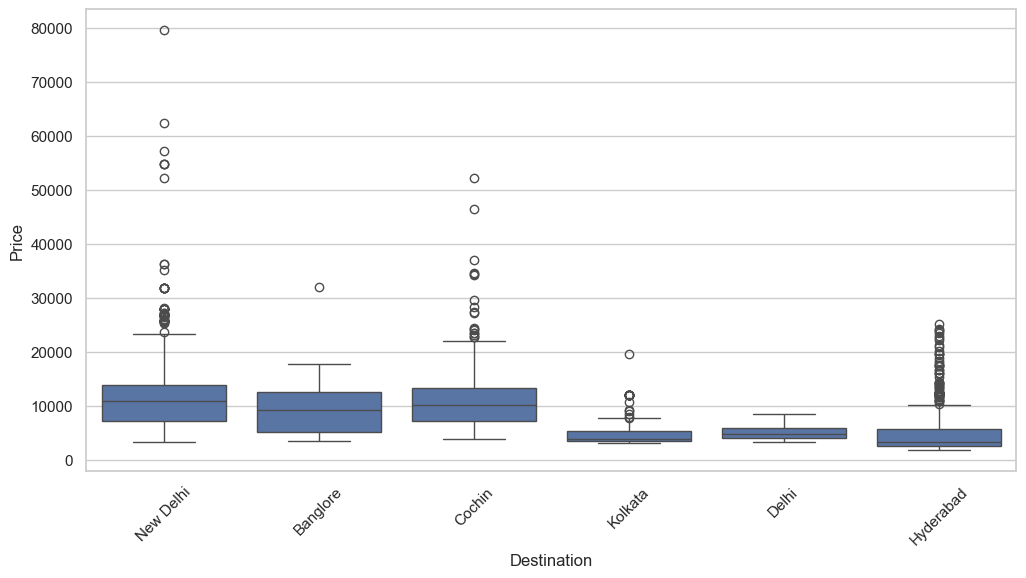

In [19]:
# Destination vs Price
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x='Destination',
    y='Price'
)

plt.xticks(rotation=45)
plt.show()

### Observation

- Ticket prices vary among destination cities.
- Certain destinations have consistently higher average fares.

### Business Insight

Destination affects ticket prices because travel demand, route popularity, and operational costs differ across cities. High-demand destinations often command higher ticket prices.

### Conclusion

Destination is an important determinant of airline ticket pricing.

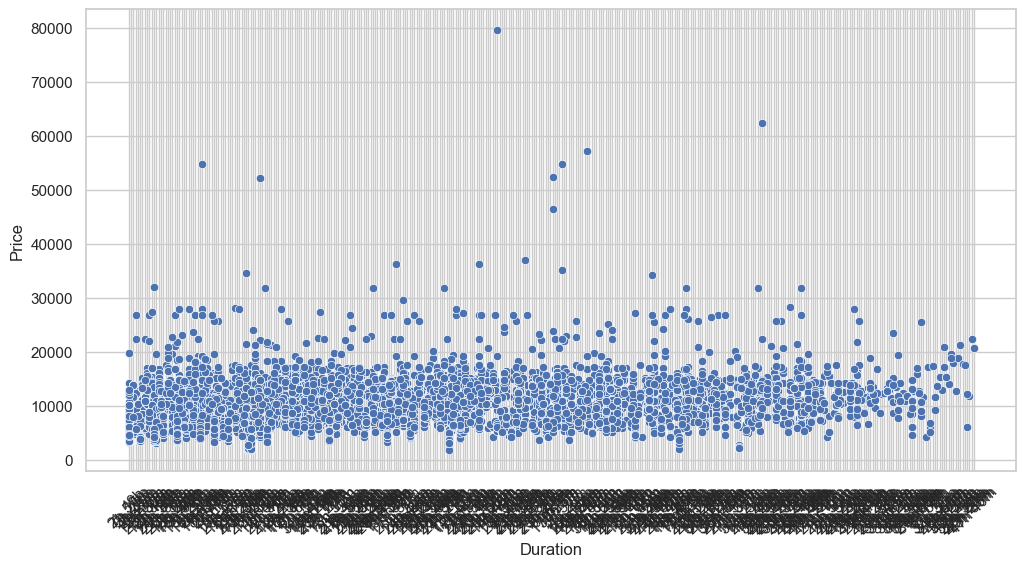

In [27]:
# Duration vs Price
plt.figure(figsize=(12,6))

sns.scatterplot(
    data=df,
    x='Duration',
    y='Price'
)

plt.xticks(rotation=45)
plt.show()

### Observation

- The scatter plot illustrates how ticket prices change with flight duration.
- An upward trend would suggest that longer flights generally have higher ticket prices, although considerable variation may exist.
- Some flights deviate from the general pattern, indicating that additional factors also affect pricing.

### Business Insight

Flight duration influences operational costs and customer preferences, making it a significant pricing factor. However, duration alone does not fully explain ticket prices, as airline, route, and travel date also contribute.

### Conclusion

Duration has a noticeable relationship with ticket price but should be analyzed alongside other variables.

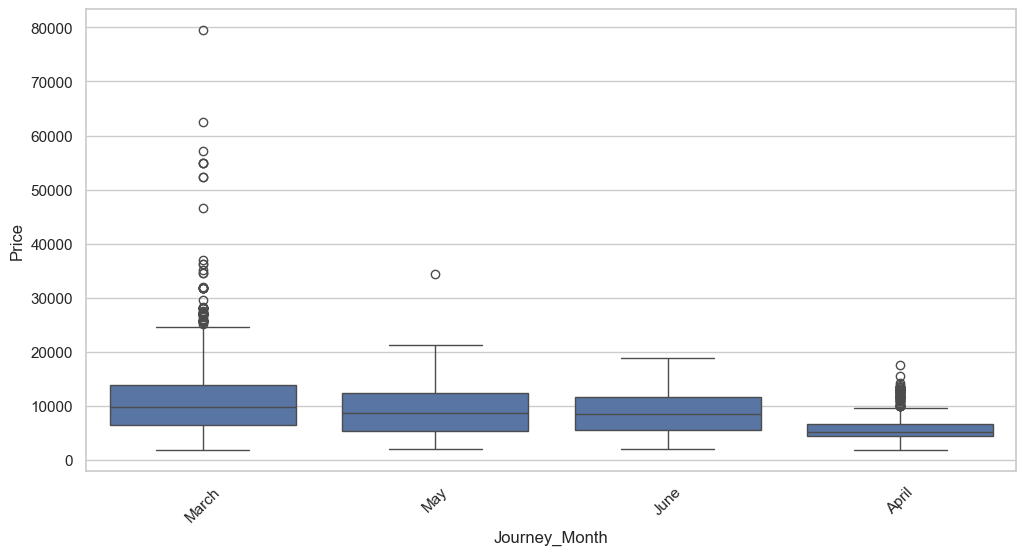

In [22]:
# Journey_Month vs Price
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x='Journey_Month',
    y='Price'
)

plt.xticks(rotation=45)
plt.show()

#### Observation:

- Average ticket prices vary across different ### Observation

- Average ticket prices fluctuate across different months.
- Some months exhibit noticeably higher average fares than others.

### Business Insight

Seasonality plays a significant role in airline pricing. Travel demand during holidays, vacations, and peak travel seasons can lead to increased ticket prices as airlines adjust fares based on market demand.

### Conclusion

Journey Month influences ticket prices and reflects seasonal travel patterns..
- Some months record higher fares, indicating the impact of seasonal travel demand.
- Lower average prices are observed during relatively less busy travel periods.
- The month of travel appears to influence ticket pricing due to seasonal fluctuations.

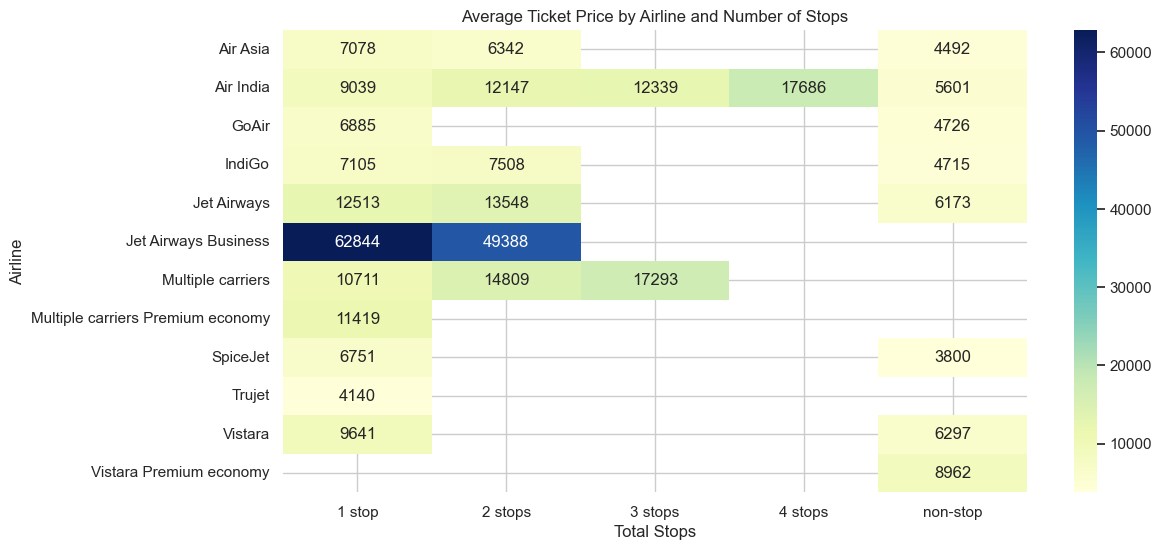

In [28]:
# ==========================================
# MULTIVARIATE ANALYSIS
# Airline vs Stops vs Price
# ==========================================

pivot_table = pd.pivot_table(
    df,
    values='Price',
    index='Airline',
    columns='Total_Stops',
    aggfunc='mean'
)

plt.figure(figsize=(12,6))

sns.heatmap(
    pivot_table,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)

plt.title("Average Ticket Price by Airline and Number of Stops")
plt.xlabel("Total Stops")
plt.ylabel("Airline")

plt.show()

### Observation

- Average ticket prices differ across airlines for each stop category.
- Some airlines consistently charge higher prices regardless of the number of stops.
- The impact of additional stops on price is not uniform across all airlines.

### Business Insight

The pricing strategy of an airline is influenced not only by the number of stops but also by the airline's market positioning. Premium airlines may maintain higher fares even for connecting flights, while budget airlines remain competitively priced.

### Conclusion

Airline and Total Stops together have a combined influence on ticket prices and should be analyzed jointly rather than independently.

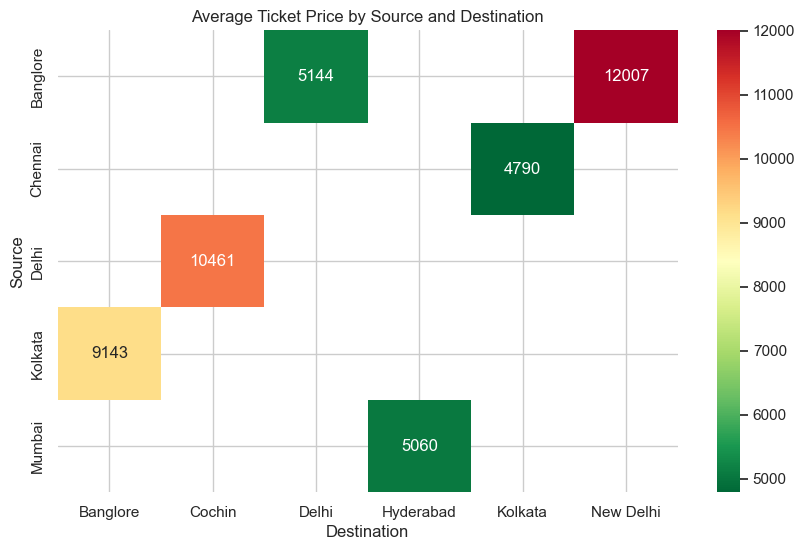

In [29]:
# ==========================================
# Source vs Destination vs Price
# ==========================================

route_price = pd.pivot_table(
    df,
    values='Price',
    index='Source',
    columns='Destination',
    aggfunc='mean'
)

plt.figure(figsize=(10,6))

sns.heatmap(
    route_price,
    annot=True,
    fmt=".0f",
    cmap="RdYlGn_r"
)

plt.title("Average Ticket Price by Source and Destination")

plt.show()

### Observation

- Average ticket prices vary considerably across source-destination pairs.
- Some routes consistently have higher fares than others.
- Not all departure cities exhibit the same pricing patterns for their destinations.

### Business Insight

The combination of departure and destination defines the travel market. Differences in demand, competition, flight availability, and operational costs across routes contribute to varying ticket prices.

### Conclusion

The Source–Destination combination is one of the strongest determinants of airline ticket pricing and provides valuable insights into route-specific pricing strategies.

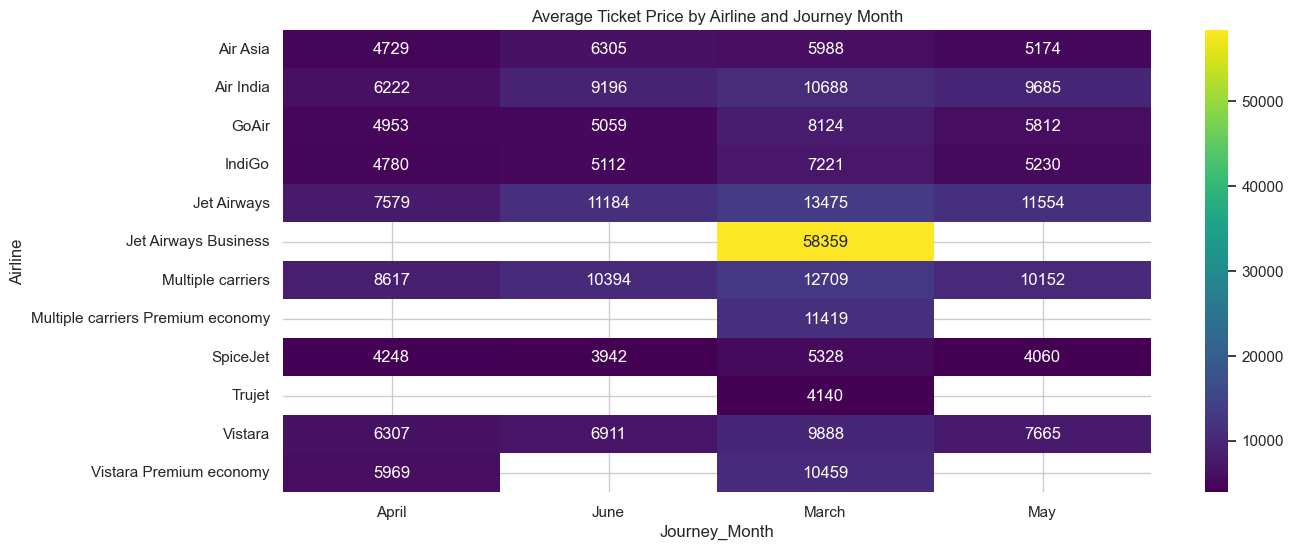

In [30]:
# ==========================================
# Airline vs Journey Month vs Price
# ==========================================

monthly_price = pd.pivot_table(
    df,
    values='Price',
    index='Airline',
    columns='Journey_Month',
    aggfunc='mean'
)

plt.figure(figsize=(14,6))

sns.heatmap(
    monthly_price,
    annot=True,
    fmt=".0f",
    cmap="viridis"
)

plt.title("Average Ticket Price by Airline and Journey Month")

plt.show()

### Observation

- Ticket prices fluctuate across different months for each airline.
- Some airlines show larger seasonal price variations than others.
- Certain months consistently have higher average fares across multiple airlines.

### Business Insight

Airlines adjust fares throughout the year in response to seasonal travel demand. Peak travel periods, holidays, and vacation seasons may result in higher ticket prices, while off-peak months often have lower fares.

### Conclusion

The interaction between Airline and Journey Month highlights the role of seasonality in pricing strategies and demonstrates that pricing decisions vary across airlines over time.

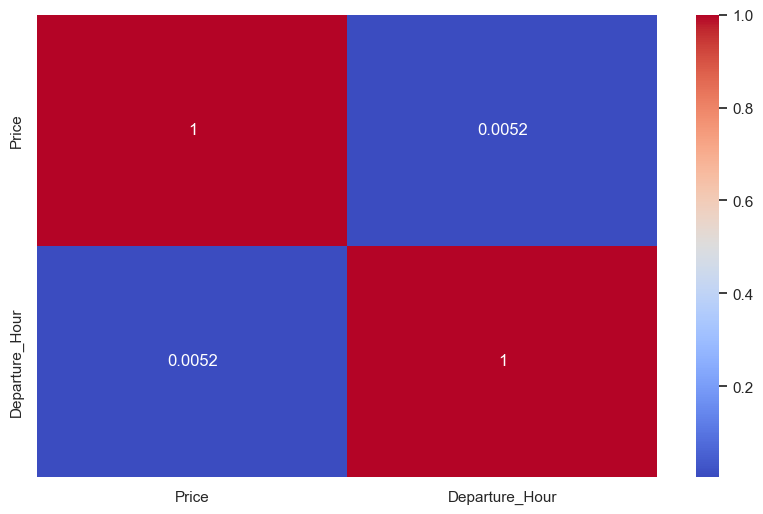

In [33]:
# ==========================================
# CORRELATION ANALYSIS
# ==========================================

numeric_df = df.select_dtypes(include='number')

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.show()

### Observation

- The correlation coefficient between **Price** and **Departure_Hour** is **0.0052**.
- This value is very close to zero, indicating virtually no linear relationship between the two variables.
- Based on this dataset, flights departing at different hours do not exhibit a consistent increase or decrease in ticket prices.

### Business Insight

The analysis suggests that **departure time alone is not a significant driver of airline ticket prices**. Airlines are more likely to determine fares based on other factors such as the airline, route, journey duration, number of stops, and travel demand rather than the hour of departure.

### Conclusion

Departure hour has a negligible influence on ticket prices in this dataset. To better understand airline pricing strategies, greater emphasis should be placed on variables such as **Airline, Route, Total Stops, Duration, Source, Destination, and Journey Month**, which are expected to have a stronger impact on ticket prices.

# Summarizing The findings

# Business Insights

The exploratory data analysis identified several key factors that influence airline ticket prices. The following insights summarize the main findings and their business implications.

---

## Insight 1: Airline Significantly Influences Ticket Prices

**Finding**

Ticket prices vary considerably across different airlines. Some airlines consistently charge higher average fares than others.

**Business Interpretation**

This suggests that airlines follow different pricing strategies based on their market positioning, service offerings, and target customer segments. Premium airlines generally command higher fares, while low-cost carriers compete on price.

**Business Impact**

Airlines can benchmark their pricing against competitors, while travel companies can recommend airlines based on customers' budget preferences.

---

## Insight 2: Flight Duration Affects Ticket Prices

**Finding**

Longer flights generally tend to have higher ticket prices than shorter flights.

**Business Interpretation**

Flights with longer durations often require greater operational resources, including fuel consumption, aircraft utilization, and crew time, which contributes to higher fares.

**Business Impact**

Duration should be considered an important pricing factor when planning routes or estimating ticket costs.

---

## Insight 3: Number of Stops Influences Pricing

**Finding**

Ticket prices differ across flights with different numbers of stops.

**Business Interpretation**

The number of stops affects passenger convenience and operational planning. Direct flights often command higher prices because they reduce travel time and improve customer convenience.

**Business Impact**

Travel agencies can recommend connecting flights to price-sensitive customers while promoting non-stop flights to customers prioritizing convenience.

---

## Insight 4: Route Plays a Major Role in Pricing

**Finding**

Average ticket prices vary across different source–destination routes.

**Business Interpretation**

Demand, competition, flight frequency, and operational costs differ between routes, leading to noticeable variations in ticket prices.

**Business Impact**

Airlines can identify premium routes and optimize pricing strategies according to market demand.

---

## Insight 5: Seasonal Travel Patterns Influence Ticket Prices

**Finding**

Average ticket prices fluctuate across journey months.

**Business Interpretation**

Airlines adjust prices in response to seasonal demand, holidays, and vacation periods.

**Business Impact**

Understanding seasonal pricing patterns helps airlines improve revenue management and assists travelers in identifying more economical travel periods.

---

## Insight 6: Departure Hour Has Minimal Influence on Ticket Prices

**Finding**

The correlation analysis showed a negligible relationship between departure hour and ticket price.

**Business Interpretation**

Departure time alone does not explain fare differences. Other variables such as airline, route, duration, and number of stops have a greater influence on ticket pricing.

**Business Impact**

Pricing strategies should focus on variables with stronger influence rather than departure hour alone.

---

# Overall Business Insight

The analysis indicates that airline ticket prices are determined by a combination of airline-specific pricing strategies, journey characteristics, and route-related factors. Variables such as airline, route, duration, number of stops, and seasonality have a much greater influence on ticket prices than departure time. These insights can support airlines and travel companies in making more informed, data-driven pricing decisions and improving their understanding of customer travel patterns.

# Business Recommendations

Based on the analysis of airline ticket prices, the following recommendations are proposed to support data-driven pricing decisions and improve competitiveness.

---

## Recommendation 1: Implement Dynamic Pricing Based on Demand

**Supporting Insight**

Ticket prices vary across journey months and routes, indicating that demand influences pricing.

**Recommendation**

Airlines should adopt dynamic pricing strategies that adjust fares according to seasonal demand, holidays, and route popularity to maximize revenue while remaining competitive.

**Expected Benefit**

- Increase revenue during peak travel periods.
- Improve seat occupancy during off-peak periods through competitive pricing.

---

## Recommendation 2: Optimize Route-Specific Pricing

**Supporting Insight**

Certain source–destination routes consistently have higher average ticket prices.

**Recommendation**

Develop pricing strategies tailored to individual routes instead of applying uniform pricing across all markets.

**Expected Benefit**

- Better align ticket prices with market demand.
- Improve profitability on premium routes while maintaining competitiveness on price-sensitive routes.

---

## Recommendation 3: Differentiate Pricing by Flight Characteristics

**Supporting Insight**

Flight duration and the number of stops influence ticket prices.

**Recommendation**

Consider journey duration and flight convenience when determining ticket prices. Non-stop and shorter-duration flights may justify premium pricing due to their higher customer value.

**Expected Benefit**

- Improve pricing consistency.
- Better reflect customer willingness to pay for convenience.

---

## Recommendation 4: Monitor Competitor Pricing

**Supporting Insight**

Average ticket prices differ significantly among airlines.

**Recommendation**

Regularly benchmark ticket prices against competing airlines operating similar routes to ensure pricing remains competitive while maintaining profitability.

**Expected Benefit**

- Enhance market competitiveness.
- Reduce the risk of overpricing or underpricing services.

---

## Recommendation 5: Support Customer-Centric Pricing

**Supporting Insight**

Customers have different travel priorities, including cost, travel time, and convenience.

**Recommendation**

Offer a range of pricing options based on customer preferences, such as lower-priced connecting flights for budget-conscious travelers and premium-priced direct flights for customers seeking convenience.

**Expected Benefit**

- Improve customer satisfaction.
- Appeal to a broader range of traveler segments.

---

## Recommendation 6: Continue Monitoring Pricing Trends

**Supporting Insight**

Airline ticket prices are influenced by multiple interacting factors rather than a single variable.

**Recommendation**

Regularly analyze historical flight data to identify changes in pricing patterns, customer demand, and market conditions. Updating pricing strategies based on recent data can help maintain competitiveness.

**Expected Benefit**

- Support continuous improvement in pricing decisions.
- Enable faster responses to changing market conditions.

---

# Final Recommendation

The analysis demonstrates that airline ticket prices are influenced by a combination of airline-specific strategies, route characteristics, journey duration, number of stops, and seasonal travel demand. Airlines and travel companies should adopt data-driven pricing strategies that consider these factors collectively rather than relying on any single variable. Continuous monitoring of pricing trends and customer travel patterns will support more informed decisions, improve competitiveness, and enhance overall business performance.

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10463 entries, 0 to 10682
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Airline          10463 non-null  object        
 1   Date_of_Journey  10463 non-null  datetime64[ns]
 2   Source           10463 non-null  object        
 3   Destination      10463 non-null  object        
 4   Route            10463 non-null  object        
 5   Dep_Time         10463 non-null  object        
 6   Arrival_Time     10463 non-null  object        
 7   Duration         10463 non-null  object        
 8   Total_Stops      10463 non-null  object        
 9   Additional_Info  10463 non-null  object        
 10  Price            10463 non-null  int64         
 11  Journey_Month    10463 non-null  object        
 12  Journey_Day      10463 non-null  object        
 13  Departure_Hour   10463 non-null  int32         
dtypes: datetime64[ns](1), int32(1), int64(1), o

In [34]:
# Exporting The Cleaned Data Set
df.to_csv("Clean_Flight_Data.csv", index=False)